In [ ]:
%%capture
%load_ext autoreload
%autoreload 2
%reset -f

In [ ]:
import jax
import numpy as np
import optax
from jax import numpy as jnp
from jax.numpy import fft
from matplotlib import pyplot as plt

from otf import optim
from otf import time_integration as ti
from otf.asyncd import utils
from otf.system import (
    System_ModelKnown,
)
from otf.system import (
    utils as system_utils,
)

from plot import plot

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)

jndarray = jnp.ndarray

In [ ]:
def get_initial_values(x0: float, xf: float, n: int):
    """Get initial values for the true and nudged states.

    Parameters
    ----------
    x0, xf
        Endpoints of domain
    n
        Number of spatial grid points on [x0, xf]

    Returns
    -------
    u0
        Initial true state
    un0
        Initial nudged state
    """
    # Initial true state
    u = lambda x: jnp.sin(x * 2 * np.pi / (xf - x0))
    xls = jnp.linspace(x0, xf, n, endpoint=False)
    u0 = u(xls)

    # Initial simulation state
    un0 = jnp.zeros_like(u0)

    return fft.rfft(u0), fft.rfft(un0)

In [ ]:
def compute_spatial_derivative(s: jndarray, m: int, k: jndarray) -> jndarray:
    """Compute mth spatial derivative of the state.

    Parameters
    ----------
    s
        System state (e.g., true or nudged) at a point in time
    m
        Number of spatial derivatives to take
    k
        Wave numbers

    Returns
    -------
    d^m s / d {x^m}
        Approximation of mth spatial derivative of s
    """
    return fft.irfft((2 * jnp.pi * 1j * k) ** m * fft.rfft(s))


def compute_spatial_derivative_fourier(
    s: jndarray, m: int, k: jndarray
) -> jndarray:
    """Compute mth spatial derivative of the state in the frequency domain.

    Parameters
    ----------
    s
        System state (e.g., true or nudged) at a point in time
    m
        Number of spatial derivatives to take
    k
        Wave numbers

    Returns
    -------
    d^m s / d {x^m}
        Approximation of mth spatial derivative of s
    """
    return (2 * jnp.pi * 1j * k) ** m * s


dx = compute_spatial_derivative
df = compute_spatial_derivative_fourier

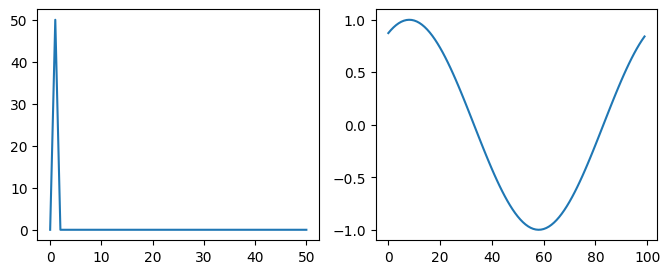

In [ ]:
def true_ode(gs: jndarray, true: jndarray, k: jndarray) -> jndarray:
    g1, g2, g3 = gs
    s = true

    return -(
        g1 * df(s, 1, k)
        # g1 * df(s, 2, k)
        # + g2 * fft.rfft(fft.irfft(s) * fft.irfft(df(s, 1, k)))
        # + g3 * df(s, 4, k)
    )


def assimilated_ode(
    cs: jndarray, assimilated: jndarray, k: jndarray
) -> jndarray:
    c1, c2, c3 = cs
    s = assimilated

    return -(
        c1 * df(s, 1, k)
        # c1 * df(s, 2, k)
        # + c2 * fft.rfft(fft.irfft(s) * fft.irfft(df(s, 1, k)))
        # + c3 * df(s, 4, k)
    )


# System evolution parameters
gs = jnp.array([1, 1, 1], dtype=float)
cs = gs
mu = 25
x0, xf = 0, 2 * np.pi
xn = 100
k = fft.rfftfreq(xn, (xf - x0) / xn)

true0, assimilated0 = get_initial_values(x0, xf, xn)

flat_true_ode = system_utils.flatten_ode(
    lambda gs, true: true_ode(gs, true, k),
    true0.shape,
)
flat_assimilated_ode = system_utils.flatten_ode(
    lambda cs, assimilated: assimilated_ode(cs, assimilated, k),
    assimilated0.shape,
)

observed_slice = jnp.s_[:]
observed_mask = system_utils.mask_from_slice(observed_slice, true0.shape)
system = System_ModelKnown(
    mu,
    gs,
    cs,
    observed_mask,
    flat_assimilated_ode,
    flat_true_ode,
    complex_differentiation=True,
)

solver = ti.ForwardEuler(system)
solver = ti.TwoStepAdamsBashforth(system, solver)
solver = ti.FourStepAdamsBashforth(system, solver)

# Simulation parameters
dt = 0.005
T0, Tf = 0, 200
t_relax = 1

gradient_computer = optim.gradient.AdjointGradient(
    system,
    optim.gradient.adjoint.UpdateOption.asymptotic,
    (ti.ForwardEuler, ti.TwoStepAdamsBashforth),
    dt,
)
optimizer = optax.adam(1e-2)
optimizer = optim.OptaxWrapper(system, optimizer, gradient_computer)

true_ode(gs, true0, k)

true, tls_ = solver.solve_true(true0.ravel(), T0, Tf, dt)
true_observed = true[:, observed_mask]

i = -1
a = true[i]
fig, axs = plt.subplots(1, 2, figsize=(8, 3))
axs[0].plot(abs(a))
axs[1].plot(fft.irfft(a))
plt.show()

In [ ]:
return_all = True
cs, u_errors, tls, assimilated = utils.run_update(
    system,
    true_observed,
    solver,
    dt,
    T0,
    Tf,
    t_relax,
    assimilated0.ravel(),
    optimizer,
    return_all=return_all,
)

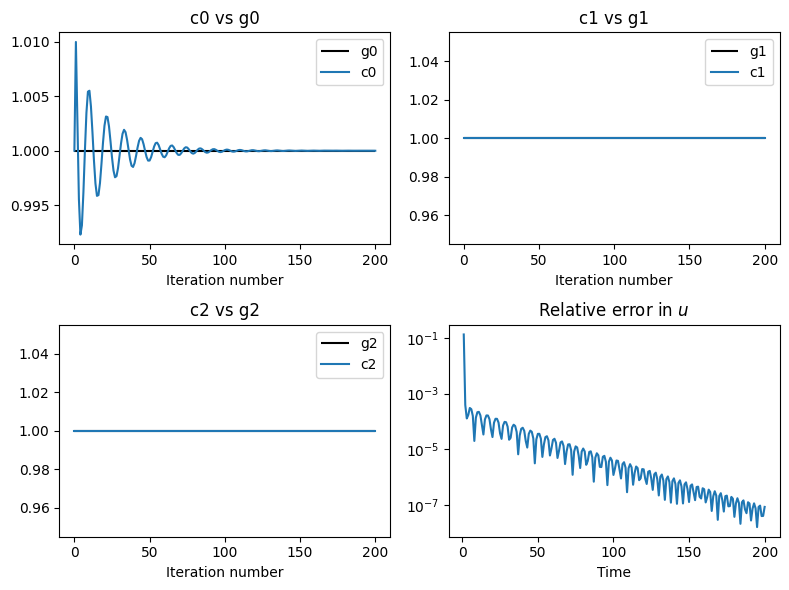

In [ ]:
fig, axs = plot(cs, u_errors, gs, tls)
plt.show()